In [4]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
target = new_client.target
target_query = target.search('mmp9')
targets = pd.DataFrame.from_dict(target_query)
targets.head()

,cross_references,organism,pref_name,score,species_group_flag,target_chembl_id,target_components,target_type,tax_id
0,[],Rattus norvegicus,Matrix metalloproteinase-9,15.0,False,CHEMBL3870,"[{'accession': 'P50282', 'component_descriptio...",SINGLE PROTEIN,10116
1,[],Mus musculus,Matrix metalloproteinase-9,15.0,False,CHEMBL2214,"[{'accession': 'P41245', 'component_descriptio...",SINGLE PROTEIN,10090
2,[],Bos taurus,Matrix metalloproteinase-9,15.0,False,CHEMBL5846,"[{'accession': 'P52176', 'component_descriptio...",SINGLE PROTEIN,9913
3,[],Homo sapiens,Matrix metalloproteinase-9,13.0,False,CHEMBL321,"[{'accession': 'P14780', 'component_descriptio...",SINGLE PROTEIN,9606
4,[],Homo sapiens,Matrix metalloproteinase 2/9,11.0,False,CHEMBL3885505,"[{'accession': 'P08253', 'component_descriptio...",PROTEIN FAMILY,9606


In [7]:
res = new_client.activity
res_query = res.filter(target_chembl_id='CHEMBL321').filter(standard_type='IC50')
res_df = pd.DataFrame.from_dict(res_query)
res_df.head()

,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,33892,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,34.0
1,None,None,35115,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,9.0
2,None,None,35120,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,20.0
3,None,None,35125,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,3.0
4,None,None,35129,[],CHEMBL715225,In vitro inhibitory activity against matrix me...,B,None,None,BAO_0000190,...,Homo sapiens,Matrix metalloproteinase-9,9606,None,None,IC50,nM,UO_0000065,None,9.0


In [8]:
res_df.shape

(3964, 46)

In [9]:
res_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3964 entries, 0 to 3963
Data columns (total 46 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   action_type                202 non-null    object 
 1   activity_comment           1124 non-null   object 
 2   activity_id                3964 non-null   int64  
 3   activity_properties        3964 non-null   object 
 4   assay_chembl_id            3964 non-null   object 
 5   assay_description          3964 non-null   object 
 6   assay_type                 3964 non-null   object 
 7   assay_variant_accession    17 non-null     object 
 8   assay_variant_mutation     17 non-null     object 
 9   bao_endpoint               3964 non-null   object 
 10  bao_format                 3964 non-null   object 
 11  bao_label                  3964 non-null   object 
 12  canonical_smiles           3927 non-null   object 
 13  data_validity_comment      86 non-null     objec

In [10]:
res_df.columns

Index(['action_type', 'activity_comment', 'activity_id', 'activity_properties',
       'assay_chembl_id', 'assay_description', 'assay_type',
       'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint',
       'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment',
       'data_validity_description', 'document_chembl_id', 'document_journal',
       'document_year', 'ligand_efficiency', 'molecule_chembl_id',
       'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value',
       'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id',
       'standard_flag', 'standard_relation', 'standard_text_value',
       'standard_type', 'standard_units', 'standard_upper_value',
       'standard_value', 'target_chembl_id', 'target_organism',
       'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type',
       'units', 'uo_units', 'upper_value', 'value'],
      dtype='object')

In [23]:
print(res_df['pchembl_value'].describe())

count     2411
unique     490
top       8.70
freq        54
Name: pchembl_value, dtype: object


In [27]:
res_df['pchembl_value'] = pd.to_numeric(res_df['pchembl_value'], errors='coerce')

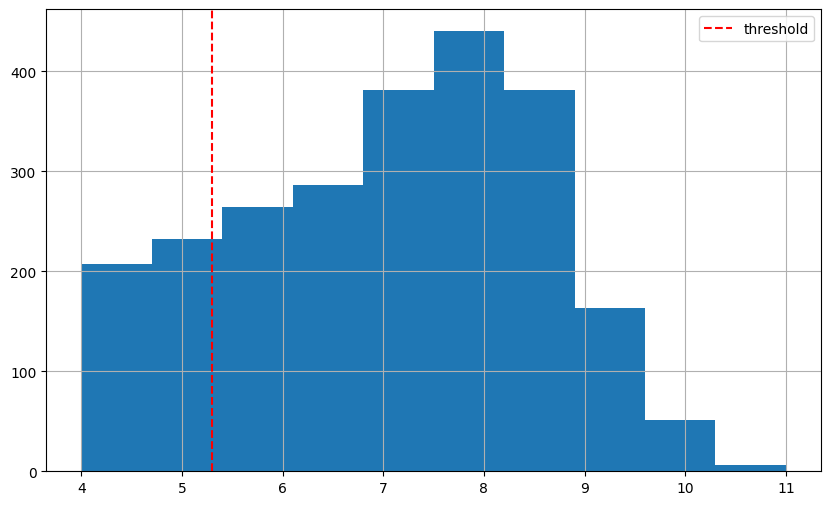

In [33]:
res_df['pchembl_value'].hist(figsize=(10,6))
plt.axvline(x=5.3, color='red', linestyle='--', label='threshold')
plt.legend()
plt.show()

In [34]:
print(res_df['standard_type'].value_counts())

standard_type
IC50    3964
Name: count, dtype: int64


In [35]:
print(res_df['standard_relation'].value_counts())

standard_relation
=     2464
>      461
<       16
<=       2
~        1
Name: count, dtype: int64


In [36]:
res_df = res_df[res_df['standard_relation'] == '=']
res_df = res_df.dropna(subset=['pchembl_value', 'canonical_smiles'])
res_df['bioactivity_class'] = (res_df['pchembl_value'] >= 5.3).astype(int)
print(res_df['bioactivity_class'].value_counts())

bioactivity_class
1    2009
0     402
Name: count, dtype: int64


In [37]:
print(res_df['assay_type'].value_counts())

assay_type
B    2397
A      14
Name: count, dtype: int64


In [38]:
res_df = res_df[res_df['assay_type'] == 'B']
print(res_df['bioactivity_class'].value_counts())

bioactivity_class
1    1996
0     401
Name: count, dtype: int64


In [39]:
clean_df = res_df[['molecule_chembl_id', 'canonical_smiles', 'pchembl_value', 'bioactivity_class']]
clean_df.to_csv('mmp9_clean.csv', index=False)
print(clean_df.shape)

(2397, 4)
